**Run Sim files before using the Notebook!** \
This Notebook constructs the plots related to the infidelity and the gamma overhead after the csv. files are constructed by the simulation files inside thesis/sim

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /home/ubuntu/qecsim


**Overhead-Factor/ Physical Error Probability**

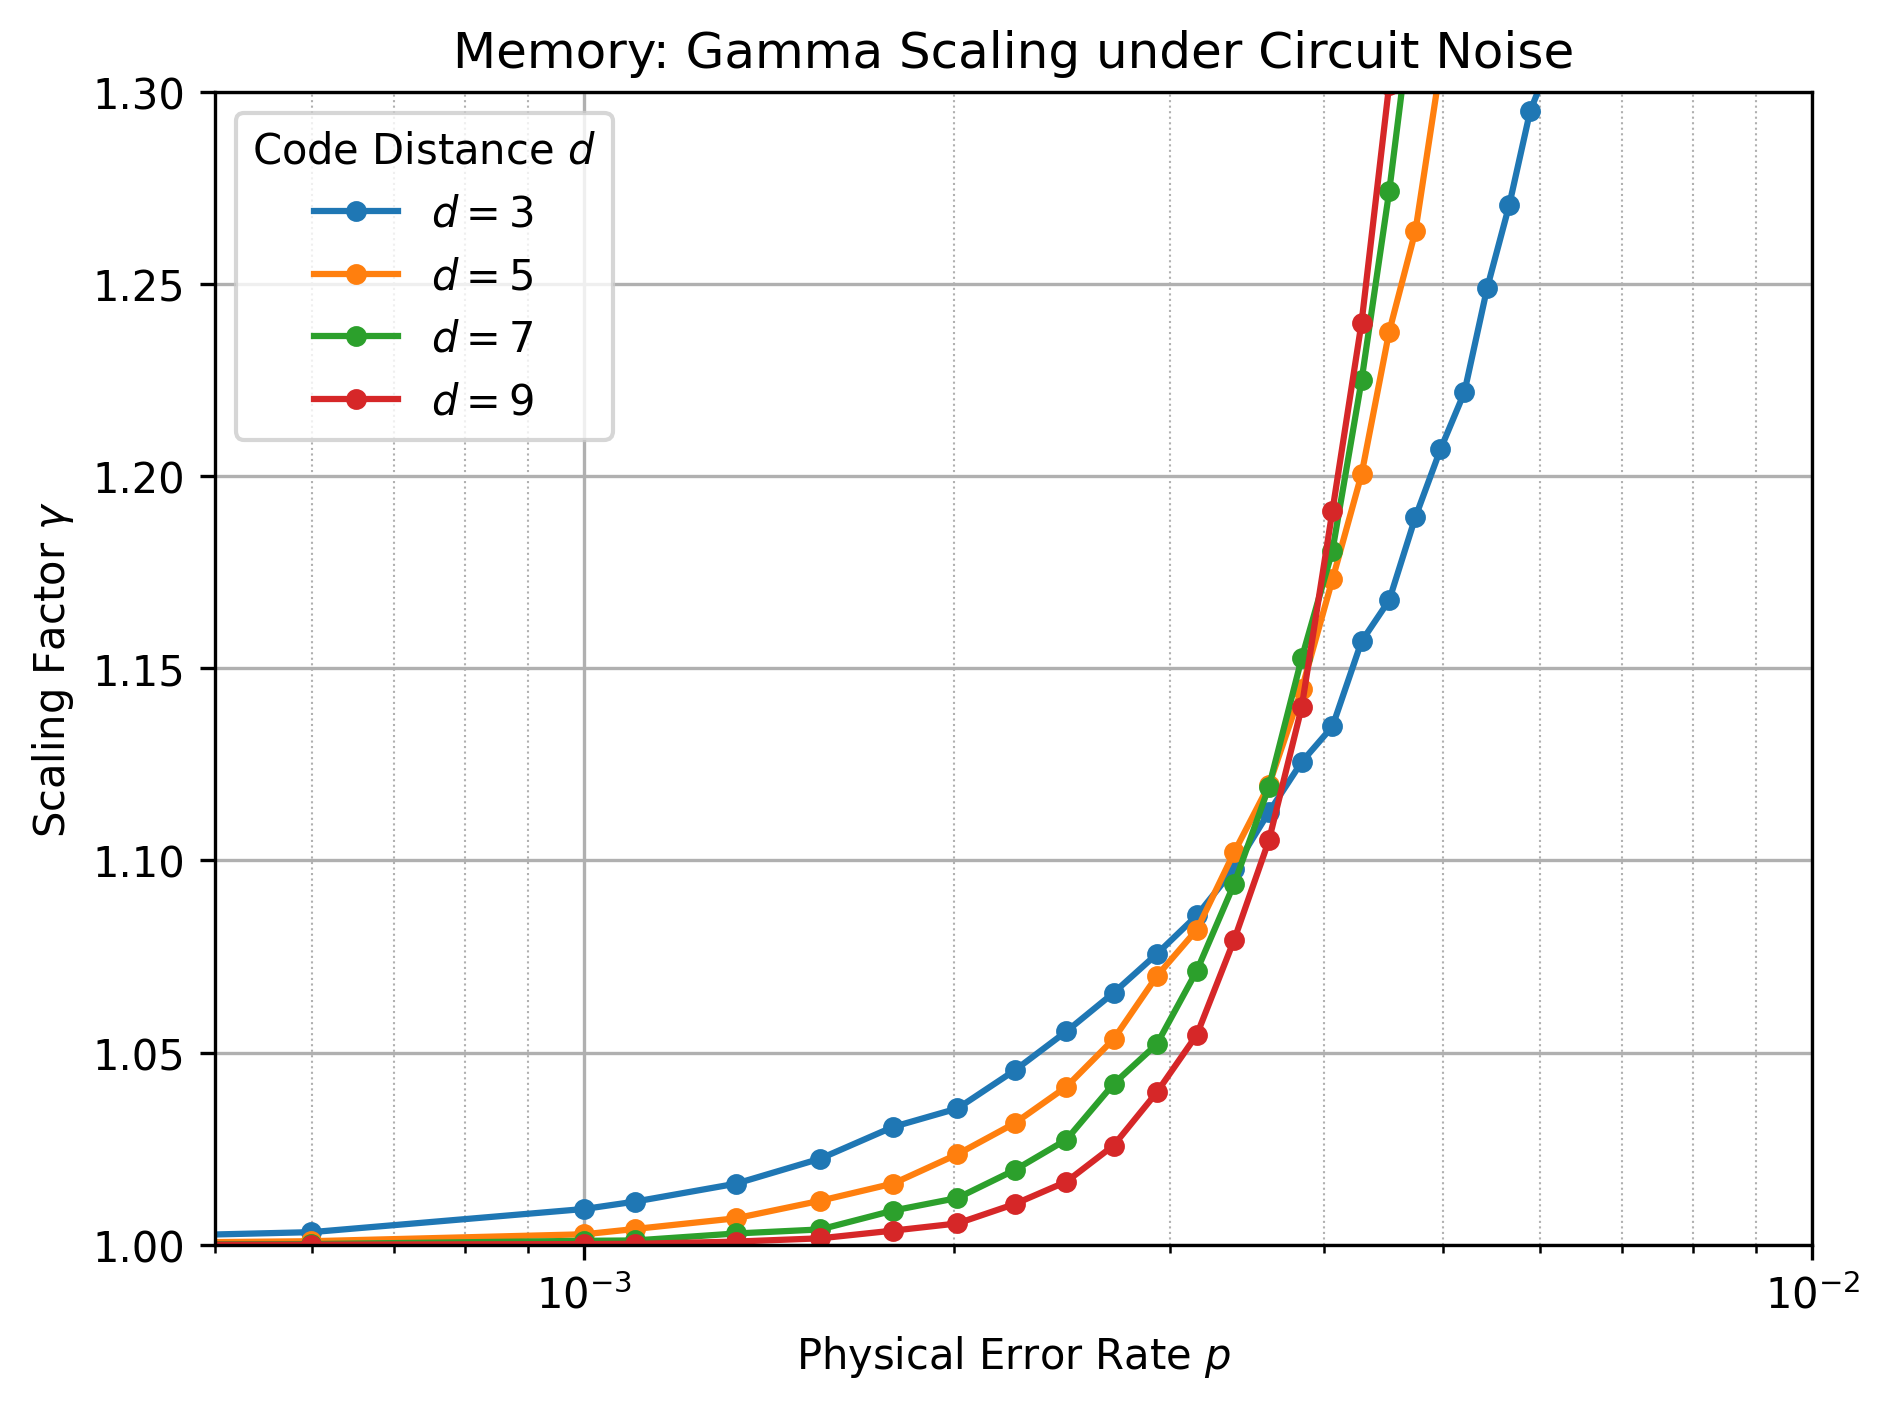

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('../data/gamma_memory.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1)

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 1.3)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log') 
ax.set_title("Memory: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

# Moved legend to upper right to avoid the inset box
ax.legend(title="Code Distance $d$", loc='upper left')

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_memory_d3579.pdf", bbox_inches='tight')

plt.show()

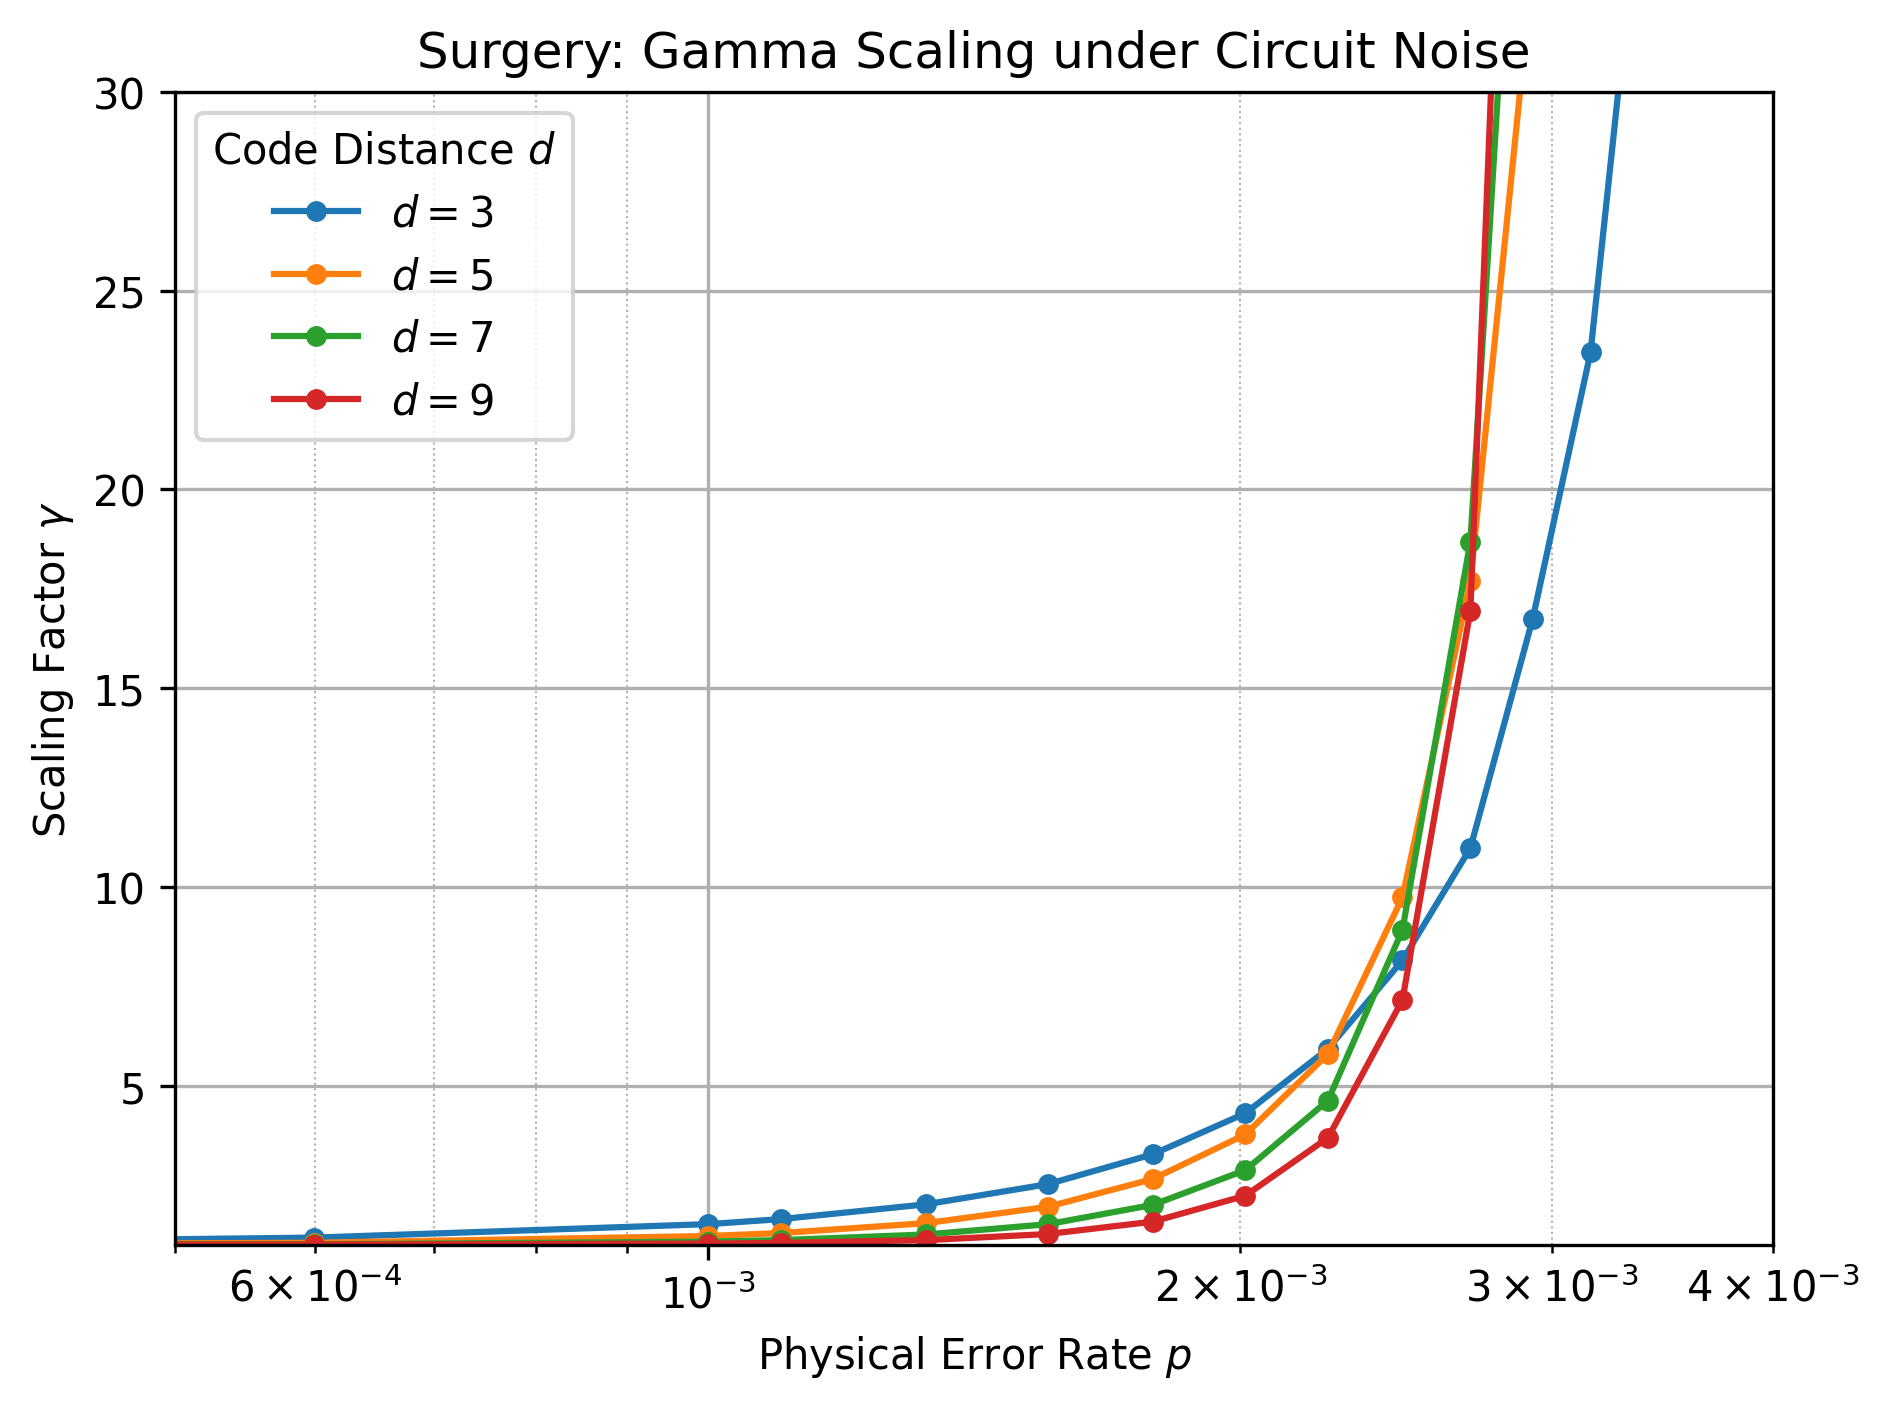

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('../data/gamma_surgery.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1)

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 30.0)
ax.set_xlim(5e-4, 4e-3)
ax.set_xscale('log') 
ax.set_title("Surgery: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

# Moved legend to upper right to avoid the inset box
ax.legend(title="Code Distance $d$", loc='upper left')

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_surgery_d3579.pdf", bbox_inches='tight')

plt.show()

In [6]:
import numpy as np

In [7]:
# Calculate the infidelities around the threshold for the d=7,9 memory cases

# Load the matrices for d=3,5,7,9
ptm_d3_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d3_CircuitNoise.npy")
ptm_d5_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d7_CircuitNoise.npy")
ptm_d9_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d9_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.concatenate([
    np.geomspace(1e-5, 1e-3, 10),
    np.linspace(1.1e-3, 1e-2, 40),
])
ptm_d3_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d3_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d9_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d9_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 4
    return 1 - fidelity

# Calculate infidelities for d=3,5,7,9
infidelities_d3 = [calculate_infidelity(ptm_d3_ideal, ptm_noisy) for ptm_noisy in ptm_d3_noisy]
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]
infidelities_d9 = [calculate_infidelity(ptm_d9_ideal, ptm_noisy) for ptm_noisy in ptm_d9_noisy]

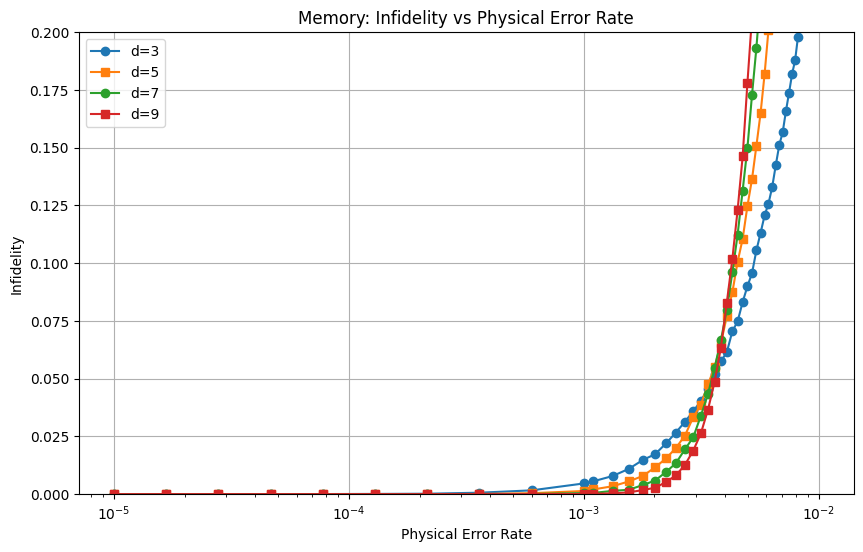

In [8]:
# Plotting infidelity vs physical error rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(probs, infidelities_d3, 'o-', label='d=3')
plt.plot(probs, infidelities_d5, 's-', label='d=5')
plt.plot(probs, infidelities_d7, 'o-', label='d=7')
plt.plot(probs, infidelities_d9, 's-', label='d=9')
plt.ylim(0,0.2)
plt.xscale('log')
plt.xlabel('Physical Error Rate')
plt.ylabel('Infidelity')
plt.title('Memory: Infidelity vs Physical Error Rate')
plt.legend()
plt.grid(True)

# Save plot as PDF
plt.savefig("../plots/Memory_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()

In [9]:
# Calculate the infidelities around the threshold for the d=7,9 memory cases

# Load the matrices for d=3,5,7,9
ptm_d3_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d3_CircuitNoise.npy")
ptm_d5_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d7_CircuitNoise.npy")
ptm_d9_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d9_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
ps = np.concatenate([
    np.geomspace(1e-5, 1e-3, 10),
    np.linspace(1.1e-3, 1e-2, 40),
])
ptm_d3_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d3_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d9_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d9_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16
    return 1 - fidelity

# Calculate infidelities for d=3,5,7,9
infidelities_d3 = [calculate_infidelity(ptm_d3_ideal, ptm_noisy) for ptm_noisy in ptm_d3_noisy]
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]
infidelities_d9 = [calculate_infidelity(ptm_d9_ideal, ptm_noisy) for ptm_noisy in ptm_d9_noisy]

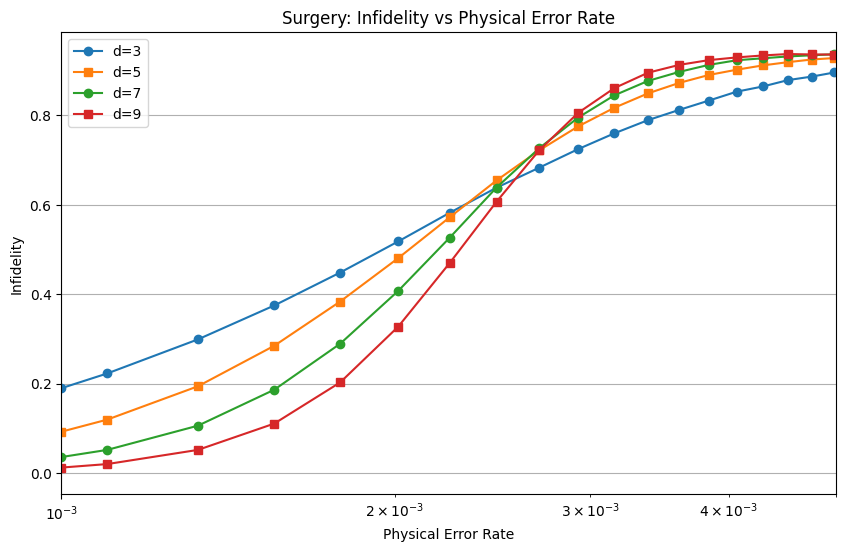

In [10]:
# Plotting infidelity vs physical error rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(probs, infidelities_d3, 'o-', label='d=3')
plt.plot(probs, infidelities_d5, 's-', label='d=5')
plt.plot(probs, infidelities_d7, 'o-', label='d=7')
plt.plot(probs, infidelities_d9, 's-', label='d=9')
plt.xscale('log')
plt.xlim(1e-3,5e-3)
plt.xlabel('Physical Error Rate')
plt.ylabel('Infidelity')
plt.grid(True)
plt.title('Surgery: Infidelity vs Physical Error Rate')
plt.legend()

# Save plot as PDF
plt.savefig("../plots/Surgery_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()

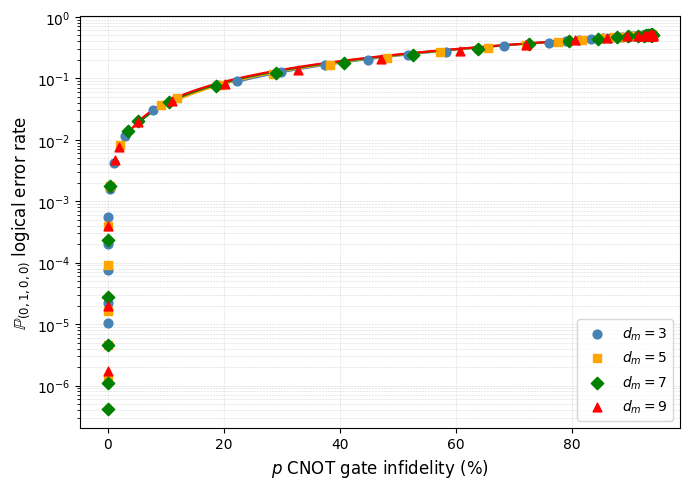

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.stats import linregress

# ── Load
df = pd.read_csv("../data/stats_surgery_X+_I0_X_X.csv", skipinitialspace=True)
df["d"] = df["json_metadata"].apply(lambda s: json.loads(s)["d"])
df["p"] = df["json_metadata"].apply(lambda s: json.loads(s)["p"])

# Keep only the entry with the most shots per (d, p)
df = df.loc[df.groupby(["d", "p"])["shots"].idxmax()].reset_index(drop=True)

df["logical_error_rate"] = df["errors"] / df["shots"]
df = df[df["logical_error_rate"] > 0]

# ── ps and infidelity lookup ──────────────────────────────────────────────────
ps = np.concatenate([
    np.geomspace(1e-5, 1e-3, 10),
    np.linspace(1.1e-3, 1e-2, 40),
])

infidelity_map = {
    3: dict(zip(ps, infidelities_d3)),
    5: dict(zip(ps, infidelities_d5)),
    7: dict(zip(ps, infidelities_d7)),
    9: dict(zip(ps, infidelities_d9)),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
STYLES = {
    3: dict(color="steelblue", marker="o"),
    5: dict(color="orange",    marker="s"),
    7: dict(color="green",     marker="D"),
    9: dict(color="red",       marker="^"),
}

fig, ax = plt.subplots(figsize=(7, 5))

for d in [3, 5, 7, 9]:
    s = STYLES[d]
    subset = df[df["d"] == d].sort_values("p")

    # Direct lookup: one p → one infidelity, no interpolation needed
    idx     = [np.argmin(np.abs(ps - p)) for p in subset["p"].values]
    x_vals  = np.array([infidelity_map[d][ps[i]] * 100 for i in idx])  # in %
    y_vals  = subset["logical_error_rate"].values

    ax.scatter(x_vals, y_vals,
               color=s["color"], marker=s["marker"],
               s=40, zorder=3, label=f"$d_m={d}$")

    # Fit on lin points only (better statistics)
    lin_mask = np.array([ps[i] >= 1.1e-3 for i in idx])
    if lin_mask.sum() > 2:
        slope, intercept, *_ = linregress(np.log10(x_vals[lin_mask]),
                                          np.log10(y_vals[lin_mask]))
        x_fit = np.logspace(np.log10(x_vals[lin_mask].min()),
                            np.log10(x_vals[lin_mask].max()), 300)
        y_fit = 10 ** (intercept + slope * np.log10(x_fit))
        ax.plot(x_fit, y_fit, color=s["color"], linewidth=1.5, zorder=2)

ax.set_yscale("log")
ax.set_xlabel("$p$ CNOT gate infidelity (%)", fontsize=12)
ax.set_ylabel(r"$\mathbb{P}_{(0,1,0,0)}$ logical error rate", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("../plots/logical_error_rate_vs_infidelity.pdf")
plt.show()